## Importing Data and Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df_identity = pd.read_csv("~/ML/Data/ieee-fraud-detection/train_identity.csv")
df_transaction = pd.read_csv("~/ML/Data/ieee-fraud-detection/train_transaction.csv")

df = df_transaction.merge(df_identity, how="left", on="TransactionID")

print(f"Train shape: {df.shape}")

Train shape: (590540, 434)


## Visualizing imbalanced data

Fraud rate: 3.50%


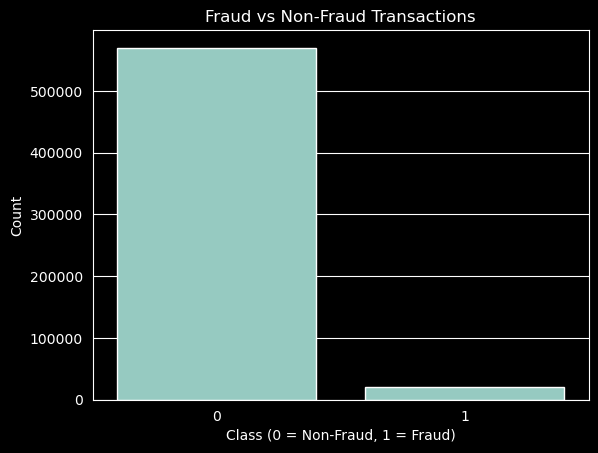

In [9]:
fraud_rate = df["isFraud"].mean()
print(f"Fraud rate: {fraud_rate:.2%}")

sns.countplot(data=df, x='isFraud')
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Class (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Count')
plt.show()

## Dropping columns with missing values

In [3]:
def missing_cols(df,threshold=0.8):
    missing_pct = df.isnull().mean() * 100
    cols_with_missing = missing_pct[missing_pct > threshold * 100]
    return cols_with_missing

In [4]:
missing_data = missing_cols(df)
print(missing_data.index)
df.drop(columns=missing_data.index,inplace=True)

Index(['dist2', 'D6', 'D7', 'D8', 'D9', 'D12', 'D13', 'D14', 'V138', 'V139',
       'V140', 'V141', 'V142', 'V143', 'V144', 'V145', 'V146', 'V147', 'V148',
       'V149', 'V150', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157',
       'V158', 'V159', 'V160', 'V161', 'V162', 'V163', 'V164', 'V165', 'V166',
       'V322', 'V323', 'V324', 'V325', 'V326', 'V327', 'V328', 'V329', 'V330',
       'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338', 'V339',
       'id_03', 'id_04', 'id_07', 'id_08', 'id_09', 'id_10', 'id_14', 'id_18',
       'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_30',
       'id_32', 'id_33', 'id_34'],
      dtype='object')


## Visualizing Fraud by Hour/Day/Month

590540


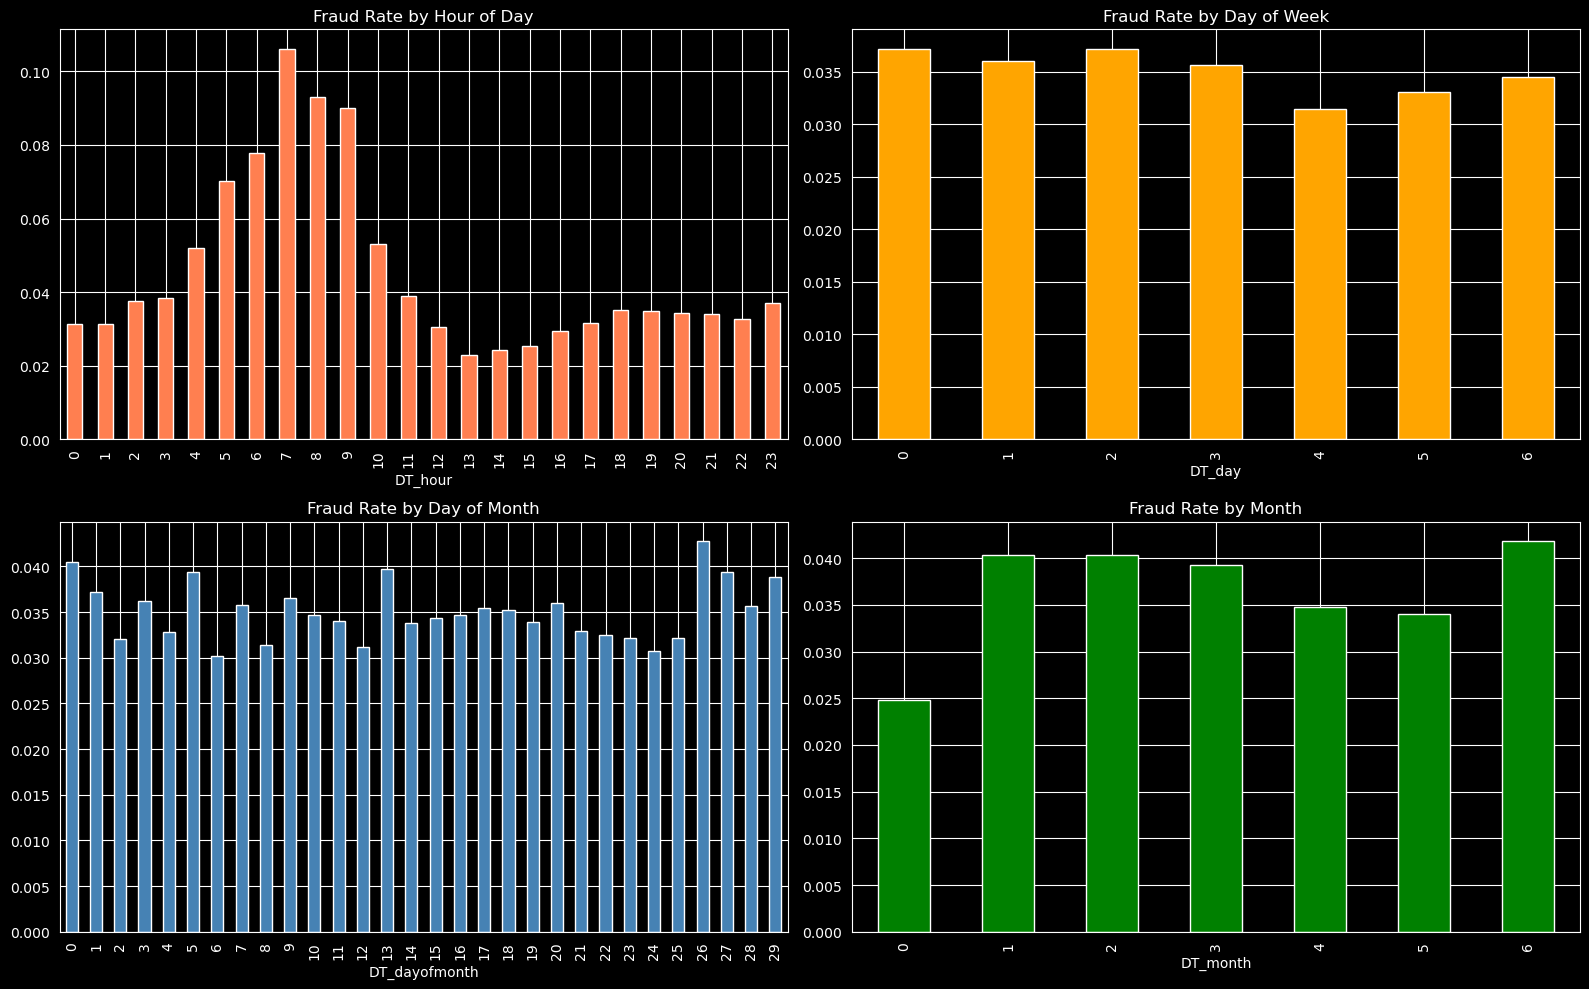

In [14]:
print(len(df))
plt.close("all")
df["DT_day"]  = (df["TransactionDT"] // (3600 * 24)) % 7
df["DT_hour"] = (df["TransactionDT"] // 3600) % 24
df["DT_dayofmonth"] = (df["TransactionDT"] // (3600 * 24)) % 30
df["DT_month"] = (df["TransactionDT"] // (3600 * 24)) // 30


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df.groupby("DT_hour")["isFraud"].mean().plot(kind="bar", ax=axes[0,0], title="Fraud Rate by Hour of Day", color="coral")
df.groupby("DT_day")["isFraud"].mean().plot(kind="bar", ax=axes[0,1], title="Fraud Rate by Day of Week", color="orange")
df.groupby("DT_dayofmonth")["isFraud"].mean().plot(kind="bar", ax=axes[1,0], title="Fraud Rate by Day of Month", color="steelblue")
df.groupby("DT_month")["isFraud"].mean().plot(kind="bar", ax=axes[1,1], title="Fraud Rate by Month", color="green")

plt.tight_layout()
plt.savefig("fraud_by_time_features.png", dpi=300, bbox_inches="tight")
plt.show()